(3, 3, 1, 32) (32,)
-0.016773691 0.2350522


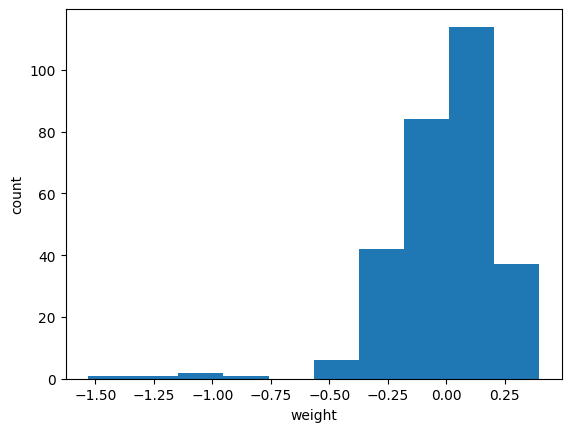

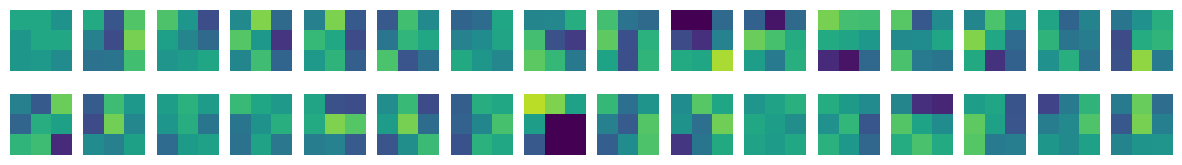

(3, 3, 1, 32)
0.0012798557 0.081867225


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


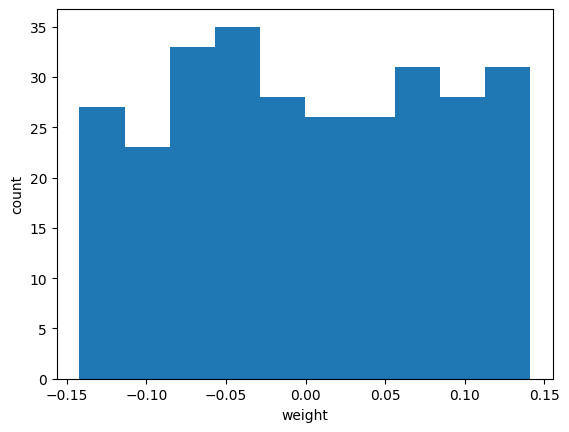

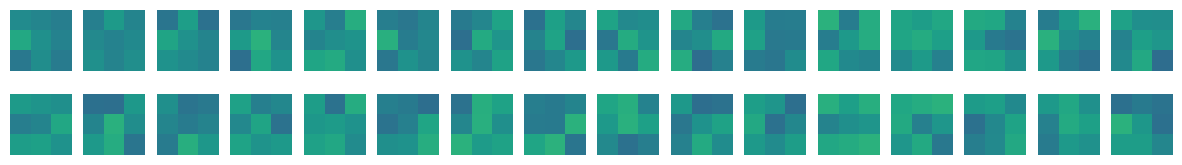

In [1]:
# 8-2에서 만든 모델 불러오기
from tensorflow import keras
model = keras.models.load_model('/content/drive/MyDrive/best-cnn-model.h5')
# 층 출력
model.layers
# 첫번째 합성곱 층의 가중치
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)
# 텐서플로의 다차원 배열->넘파이 배열로 변환
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())
# 히스토그램
import matplotlib.pyplot as plt
plt.hist(conv_weights.reshape(-1, 1)) # 히스토그램은 1차원 배열이여야함
plt.xlabel('weight')
plt.ylabel('count')
plt.show()
# 커널 출력
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

# 훈련하지않은 빈 합성곱 신경망
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                                          padding='same', input_shape=(28,28,1)))
# 가중치 저장
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)
# 넘파이 배열로 변환
no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())
# 히스토그램
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()
# 커널 출력
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

In [2]:
# 함수형 API

# 7장에서 만든 인공 신경망
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')
# 을 API로 구현
hidden = dense1(inputs)
outputs = dense2(hidden)
func_model = keras.Model(inputs,outputs)
print(model.inputs)
# 입력과 Conv2D 출력을 연결
# 다음 객체의 predict를 호출하면 첫번째 conv2D의 출력을 반환할 것임.
conv_acti = keras.Model(model.inputs, model.layers[0].output)

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer>]


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


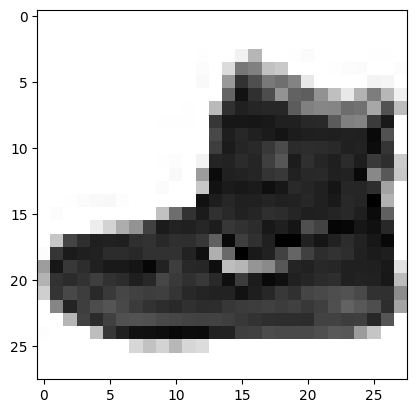

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
(1, 28, 28, 32)


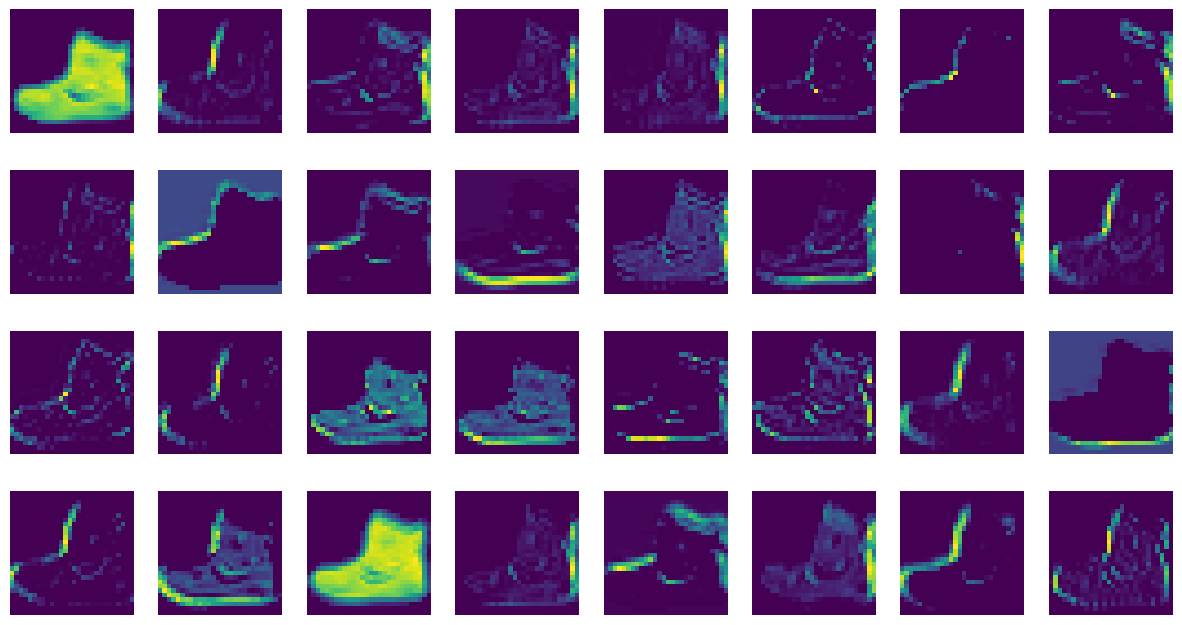

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
(1, 14, 14, 64)


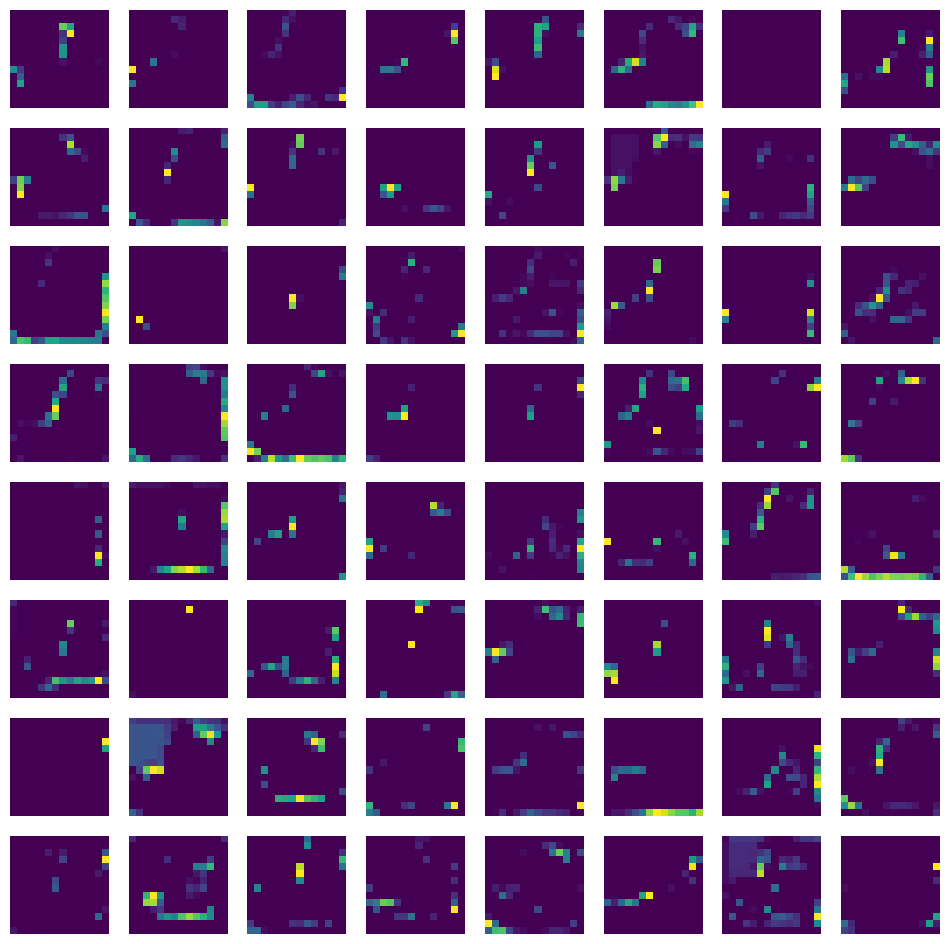

In [3]:
# 특성 맵 시각화

# 첫번째 샘플 그리기
(train_input, train_target), (test_input, test_target) = \
  keras.datasets.fashion_mnist.load_data()
plt.imshow(train_input[0], cmap='gray_r')
plt.show()
# Conv2D층이 만드는 특성 맵 출력
inputs = train_input[0:1].reshape(-1, 28, 28, 1)/255.0
feature_maps = conv_acti.predict(inputs)
print(feature_maps.shape)
fig, axs = plt.subplots(4, 8, figsize=(15,8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')
plt.show()
# 두번째 합성곱 층이 만든 특성 맵 출력
conv2_acti = keras.Model(model.inputs, model.layers[2].output)
feature_maps = conv2_acti.predict(train_input[0:1].reshape(-1, 28, 28, 1)/255.0)
print(feature_maps.shape)
fig, axs = plt.subplots(8, 8, figsize=(12,12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')
plt.show()